# Machine learning

In [3]:
import pandas as pd
import numpy as np
from pycaret.classification import *

## Loading data

In [4]:
# Load encoded feature matrices saved during feature engineering
X_train = pd.read_csv('../data/features/X_train.csv')
X_test = pd.read_csv('../data/features/X_test.csv')

# Load target vectors — squeeze converts single-column DataFrame to Series
y_train = pd.read_csv('../data/features/y_train.csv').squeeze()
y_test = pd.read_csv('../data/features/y_test.csv').squeeze()

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'y_test distribution:\n{y_test.value_counts(normalize=True).round(3)}')

X_train shape: (234436, 30)
X_test shape:  (58609, 30)
y_train distribution:
citation_top_10_percent
0    0.82
1    0.18
Name: proportion, dtype: float64
y_test distribution:
citation_top_10_percent
0    0.82
1    0.18
Name: proportion, dtype: float64


## Combining train data for PyCaret

In [5]:
# PyCaret setup() requires a single DataFrame with features + target combined
# X_test and y_test are kept separate for final evaluation after modelling
train_data = X_train.copy()
train_data['target'] = y_train.values

print(f'Train data shape: {train_data.shape}')
print(f'Target distribution:\n{train_data["target"].value_counts()}')

Train data shape: (234436, 31)
Target distribution:
target
0    192194
1     42242
Name: count, dtype: int64


##  PyCaret setup

In [6]:
# Initialise PyCaret experiment
# - target: column to predict
# - test_data: holdout set — PyCaret will never touch this during training
# - fix_imbalance: applies SMOTE to training folds only to handle 82/18 class imbalance
# - session_id: random seed for reproducibility
# - index=False: resets index to RangeIndex to avoid duplicate index error
# - verbose: shows setup summary table
experiment = setup(
    data=train_data,
    target='target',
    test_data=pd.concat([X_test, y_test.rename('target')], axis=1).reset_index(drop=True),
    fix_imbalance=True,
    session_id=42,
    index=False,
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Original data shape,"(293045, 31)"
4,Transformed data shape,"(442997, 31)"
5,Transformed train set shape,"(384388, 31)"
6,Transformed test set shape,"(58609, 31)"
7,Numeric features,30
8,Preprocess,True
9,Imputation type,simple


## Compare models

In [7]:
# Compare all available classification models
# metric: optimise ranking by F1 score — appropriate for imbalanced classification
# sort: rank models by F1
# n_select: keep top 5 models for further analysis
best_models = compare_models(
    sort='F1',
    n_select=5,
    verbose=True
)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8190,0.8413,0.5961,0.4982,0.5428,0.4311,0.4338,20.8360
ada,Ada Boost Classifier,0.7842,0.8185,0.6460,0.4336,0.5189,0.3866,0.3994,7.2210
ridge,Ridge Classifier,0.7315,0.8123,0.7511,0.3771,0.5021,0.3449,0.3833,1.6180
lda,Linear Discriminant Analysis,0.7315,0.8123,0.7511,0.3771,0.5021,0.3449,0.3833,2.5560
lr,Logistic Regression,0.7336,0.8061,0.7362,0.3774,0.4990,0.3423,0.3778,13.1660
lightgbm,Light Gradient Boosting Machine,0.8457,0.8510,0.4246,0.6017,0.4978,0.4099,0.4186,4.1540
xgboost,Extreme Gradient Boosting,0.8470,0.8519,0.4076,0.6134,0.4897,0.4040,0.4157,3.7010
catboost,CatBoost Classifier,0.8481,0.8547,0.3853,0.6282,0.4776,0.3946,0.4108,36.6040
rf,Random Forest Classifier,0.8352,0.8309,0.4007,0.5596,0.4670,0.3727,0.3800,15.3710
knn,K Neighbors Classifier,0.7088,0.7602,0.7023,0.3476,0.4650,0.2951,0.3296,18.2540


## Model Comparison Results

15 classification models were compared using 10-fold stratified cross-validation 
with SMOTE applied to training folds to handle the 82/18 class imbalance.
Models are ranked by F1 score — the primary metric for imbalanced classification.

**Winner: Gradient Boosting Classifier (gbc)**
- F1 = 0.54 — best balance of precision and recall
- AUC = 0.84 — strong class separation ability
- Beats the dummy baseline (F1 = 0.00) significantly

**Key observations:**
- XGBoost and CatBoost achieve the highest AUC (0.85) but lower F1 (0.49, 0.48)
  — they are better at overall class separation but less balanced on precision/recall
- Accuracy is a misleading metric here — the dummy classifier scores 0.82 accuracy
  by always predicting the majority class, confirming F1 is the right primary metric
- No model exceeded F1 = 0.55 — expected given only metadata features are available
  at publication time, with no full text, author network or venue quality signals
- GBC is selected for hyperparameter tuning and SHAP analysis

## SHAP analysis - GBC model

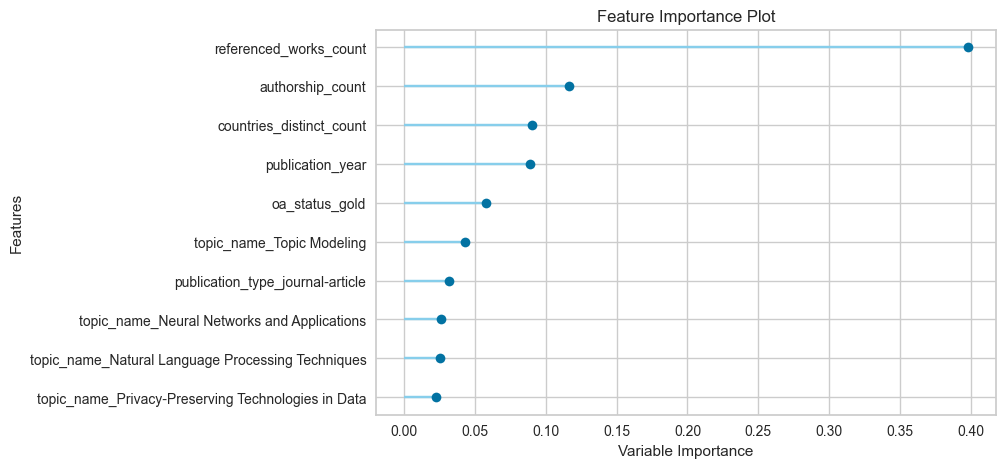

In [8]:
# Plot feature importance for the best model
plot_model(best_models[0], plot='feature')

In [10]:
help(plot_model)

Help on function plot_model in module pycaret.classification.functional:

plot_model(estimator, plot: str = 'auc', scale: float = 1, save: bool = False, fold: Union[int, Any, NoneType] = None, fit_kwargs: Optional[dict] = None, plot_kwargs: Optional[dict] = None, groups: Union[str, Any, NoneType] = None, verbose: bool = True, display_format: Optional[str] = None) -> Optional[str]
    This function analyzes the performance of a trained model on holdout set.
    It may require re-training the model in certain cases.
    
    Example
    -------
    >>> from pycaret.datasets import get_data
    >>> juice = get_data('juice')
    >>> from pycaret.classification import *
    >>> exp_name = setup(data = juice,  target = 'Purchase')
    >>> lr = create_model('lr')
    >>> plot_model(lr, plot = 'auc')
    
    
    estimator: scikit-learn compatible object
        Trained model object
    
    
    plot: str, default = 'auc'
        List of available plots (ID - Name):
    
        * 'pipeline'

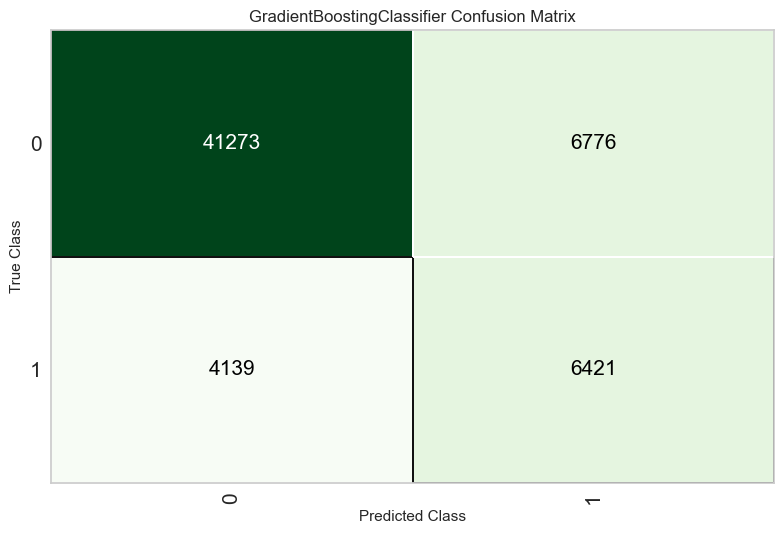

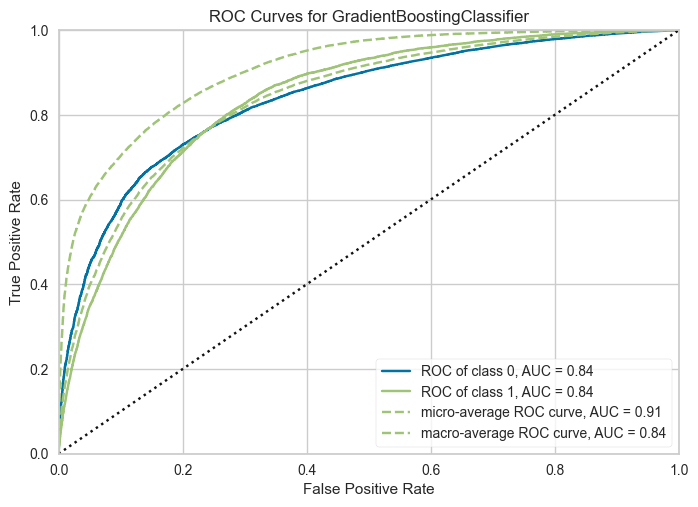

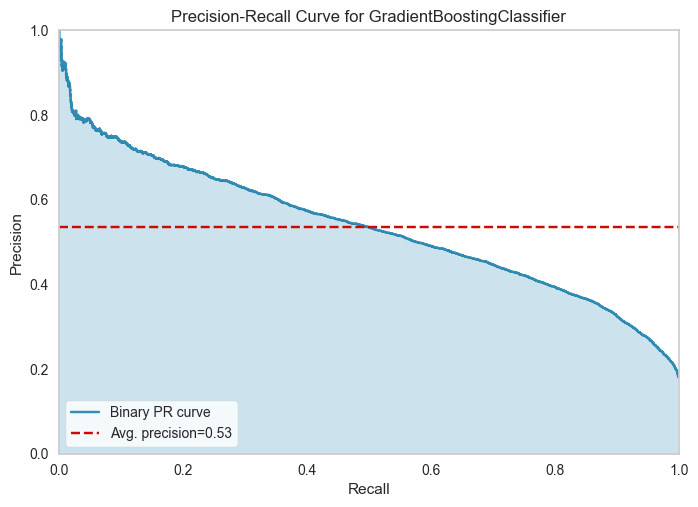

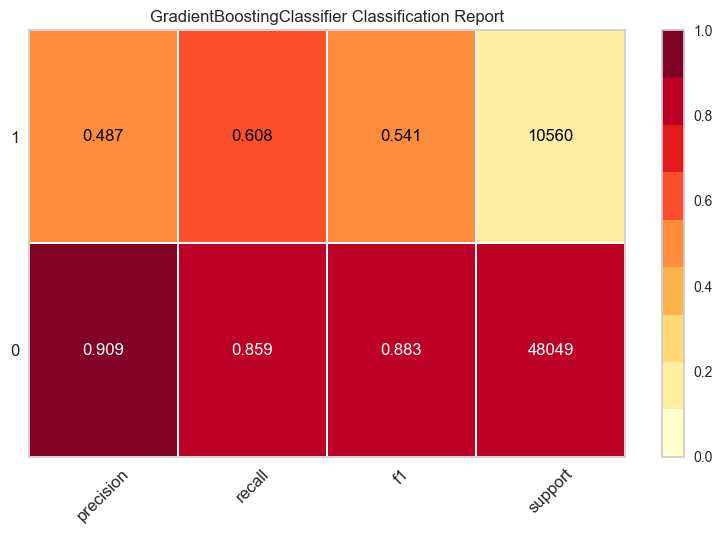

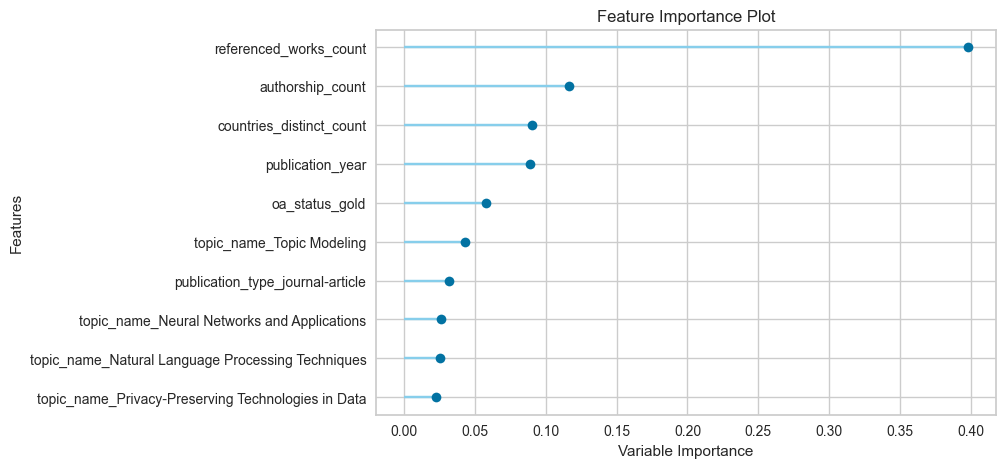

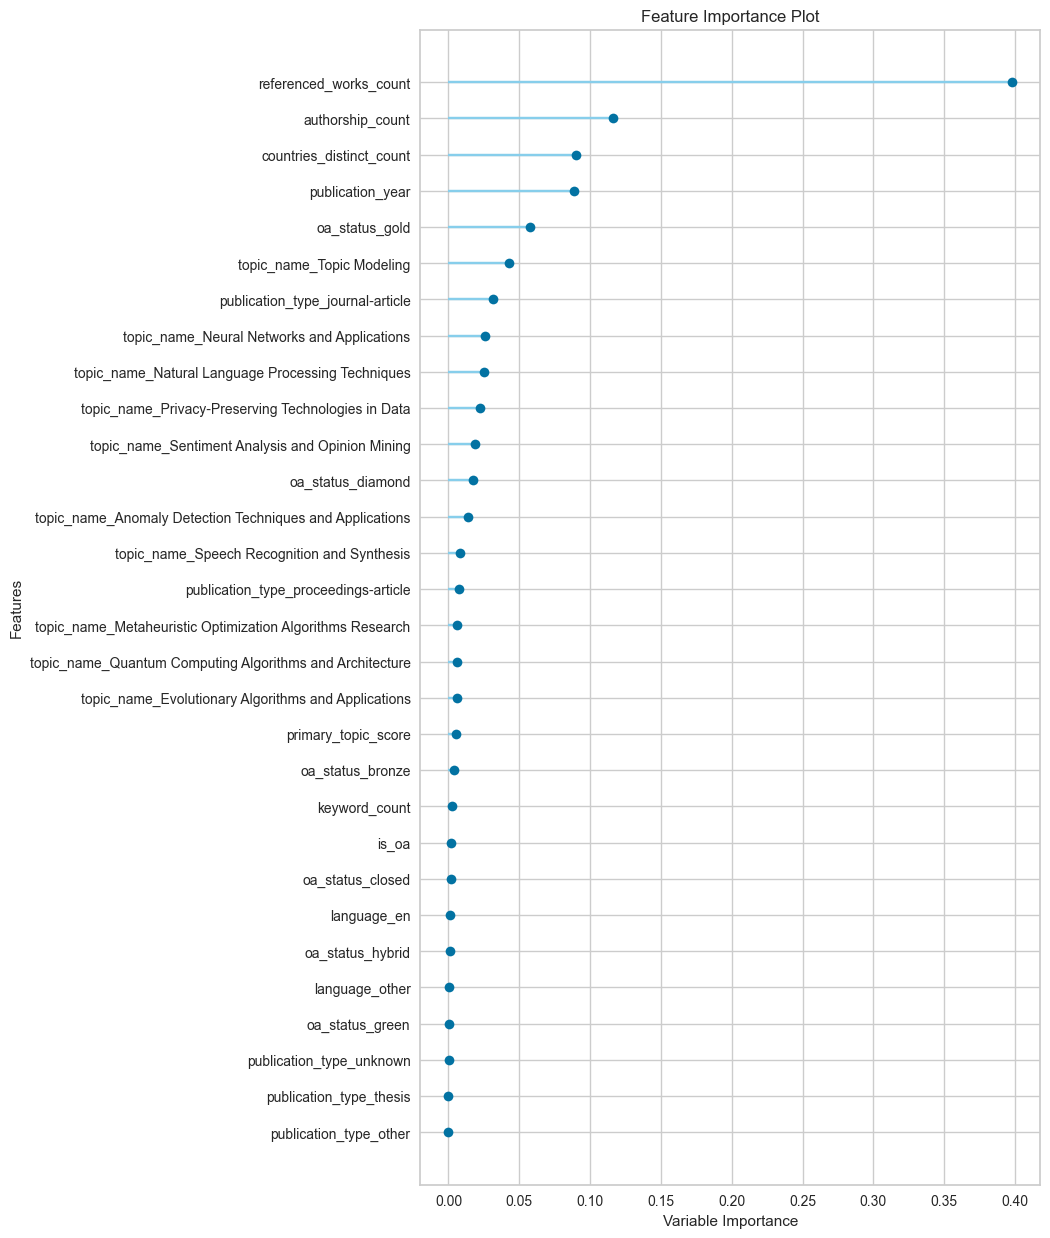

In [12]:
# Confusion matrix — shows true/false positives and negatives
plot_model(best_models[0], plot='confusion_matrix')

# AUC-ROC curve
plot_model(best_models[0], plot='auc')

# Precision-Recall curve — more informative than AUC for imbalanced data
plot_model(best_models[0], plot='pr')

# Classification report — precision, recall, F1 per class
plot_model(best_models[0], plot='class_report')

# Feature importance
plot_model(best_models[0], plot='feature')

# Feature importance
plot_model(best_models[0], plot='feature_all')

## Model Evaluation — Gradient Boosting Classifier

### Performance Summary
The Gradient Boosting Classifier was evaluated on the holdout test set of 58,609 papers.

| Metric | Score |
|---|---|
| F1 (high impact class) | 0.54 |
| AUC-ROC | 0.84 |
| Precision (high impact) | 0.49 |
| Recall (high impact) | 0.61 |

### Confusion Matrix
Of 10,560 actual high-impact papers in the test set:
- **6,421 correctly identified** as high impact (true positives)
- **4,139 missed** — predicted as non-high-impact (false negatives)
- **6,776 false alarms** — predicted high impact but weren't (false positives)

The model catches roughly 60% of high-impact papers, missing 4 in 10.
For a publisher use case this means a meaningful proportion of future
high-impact papers would be overlooked at submission time.

### AUC-ROC
AUC of 0.84 means that given a random high-impact and a random non-high-impact 
paper, the model correctly ranks the high-impact one higher 84% of the time.
This is a strong result for a metadata-only model.

### Precision-Recall Curve
Average precision = 0.53. The curve starts near 1.0 at low recall then drops 
sharply — the model is very confident on easy cases but struggles to capture 
more high-impact papers without increasing false positives. This is expected 
behaviour for imbalanced classification with limited features.

### Feature Importance Findings
The feature importance plot revealed a clear hierarchy:

1. `referenced_works_count` — dominant predictor (importance 0.40), nearly 4x 
   stronger than the second feature. Papers that build on more prior work tend 
   to be better connected to the research community and attract more citations.

2. `authorship_count` — second strongest (0.12). However this column actually 
   counts author-institution pairs rather than true distinct authors or institutions 
   — an OpenAlex data quality limitation identified during cleaning.

3. `countries_distinct_count` — third (0.09). International collaboration is a 
   strong signal for impact. However 25% of papers have a value of 0, likely due 
   to OpenAlex coverage gaps rather than truly single-country papers.

4. `publication_year` — fourth (0.09). Confirms the citation maturity effect —
   older papers have had more time to accumulate citations.

5. `oa_status_gold` — fifth (0.05). Gold open access papers are more widely 
   accessible and attract more citations.

Notably weak features: `keyword_count`, `primary_topic_score` and `is_oa` — 
all showed near-zero importance despite showing meaningful correlation with 
the target in EDA. The model found them redundant given the stronger features.

### Decision — Enriched Data Pull

The feature importance analysis directly informed the decision to pull additional 
data from the OpenAlex API. The goal is to enrich the two most important features 
and add new signals not currently available:

**Enriching existing features:**
- `authorship_count` → replaced with `unique_authors_count` and 
  `unique_institutions_count` — true distinct counts rather than author-institution 
  pairs, fixing the data quality issue identified during cleaning
- `countries_distinct_count` → replaced with `countries_recalculated_count` 
  extracted directly from institution country codes, resolving the 25% zero issue

**New features added:**
- `institution_edu_count`, `institution_nonprofit_count`, `institution_gov_count`,
  `institution_company_count` — institution type breakdown may signal research 
  quality and industry collaboration
- `funder_count`, `award_count` — funded research tends to be more rigorous 
  and better resourced, likely correlating with higher impact
- `funder_max_h_index`, `funder_avg_h_index` — prestigious funders (high h-index) 
  consistently back high-impact research; funder prestige may be a strong new signal
- `sdg_count`, `sdg_max_score`, `sdg_avg_score`, `sdg_numbers` — papers aligned 
  with UN Sustainable Development Goals may attract broader citation interest 
  across disciplines
- `referenced_works_avg_citations`, `referenced_works_max_citations` — since 
  `referenced_works_count` is by far the strongest feature, enriching it with 
  the quality of cited works (not just quantity) could significantly improve 
  model performance. Scale feasibility will be assessed before committing to this lookup.

## SHAP analysis - XGB model

In [13]:
# Train XGBoost model specifically for evaluation
xgboost_model = create_model('xgboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8476,0.8533,0.4195,0.6127,0.4980,0.4119,0.4222
1,0.8443,0.8509,0.4027,0.6013,0.4823,0.3949,0.4059
2,0.8479,0.8555,0.4051,0.6193,0.4898,0.4050,0.4176
3,0.8474,0.8505,0.4152,0.6131,0.4951,0.4092,0.4199
4,0.8455,0.8503,0.3938,0.6106,0.4788,0.3931,0.4061
5,0.8452,0.8485,0.4038,0.6060,0.4847,0.3979,0.4092
6,0.8467,0.8557,0.4022,0.6140,0.4861,0.4006,0.4129
7,0.8481,0.8550,0.4051,0.6202,0.4900,0.4054,0.4181
8,0.8487,0.8510,0.4086,0.6222,0.4933,0.4088,0.4213


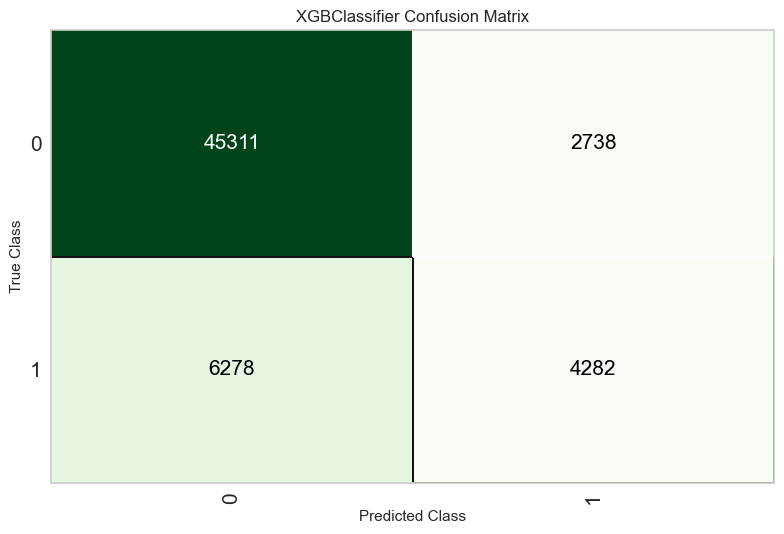

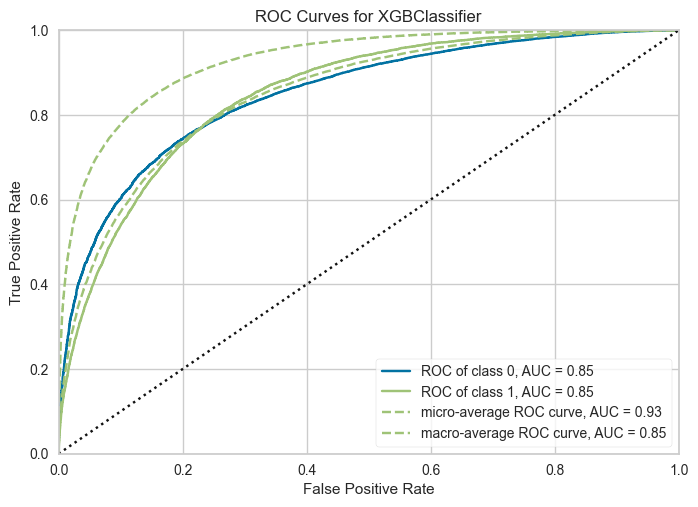

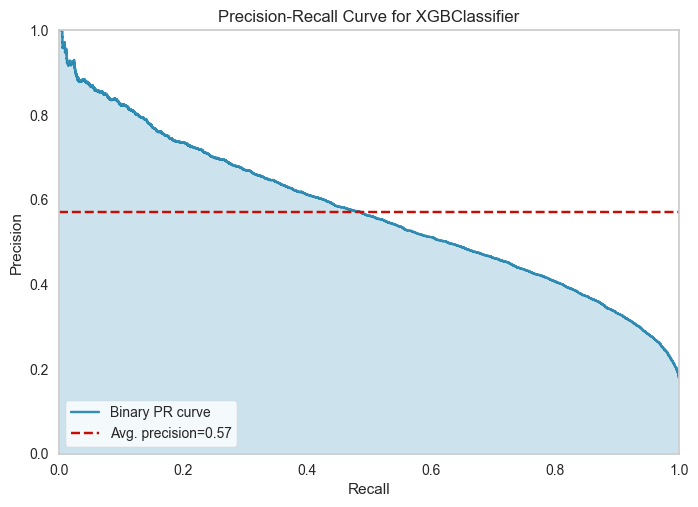

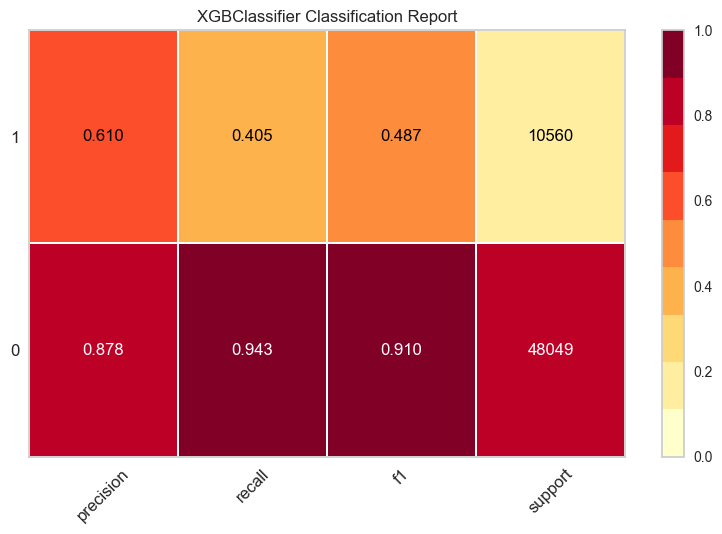

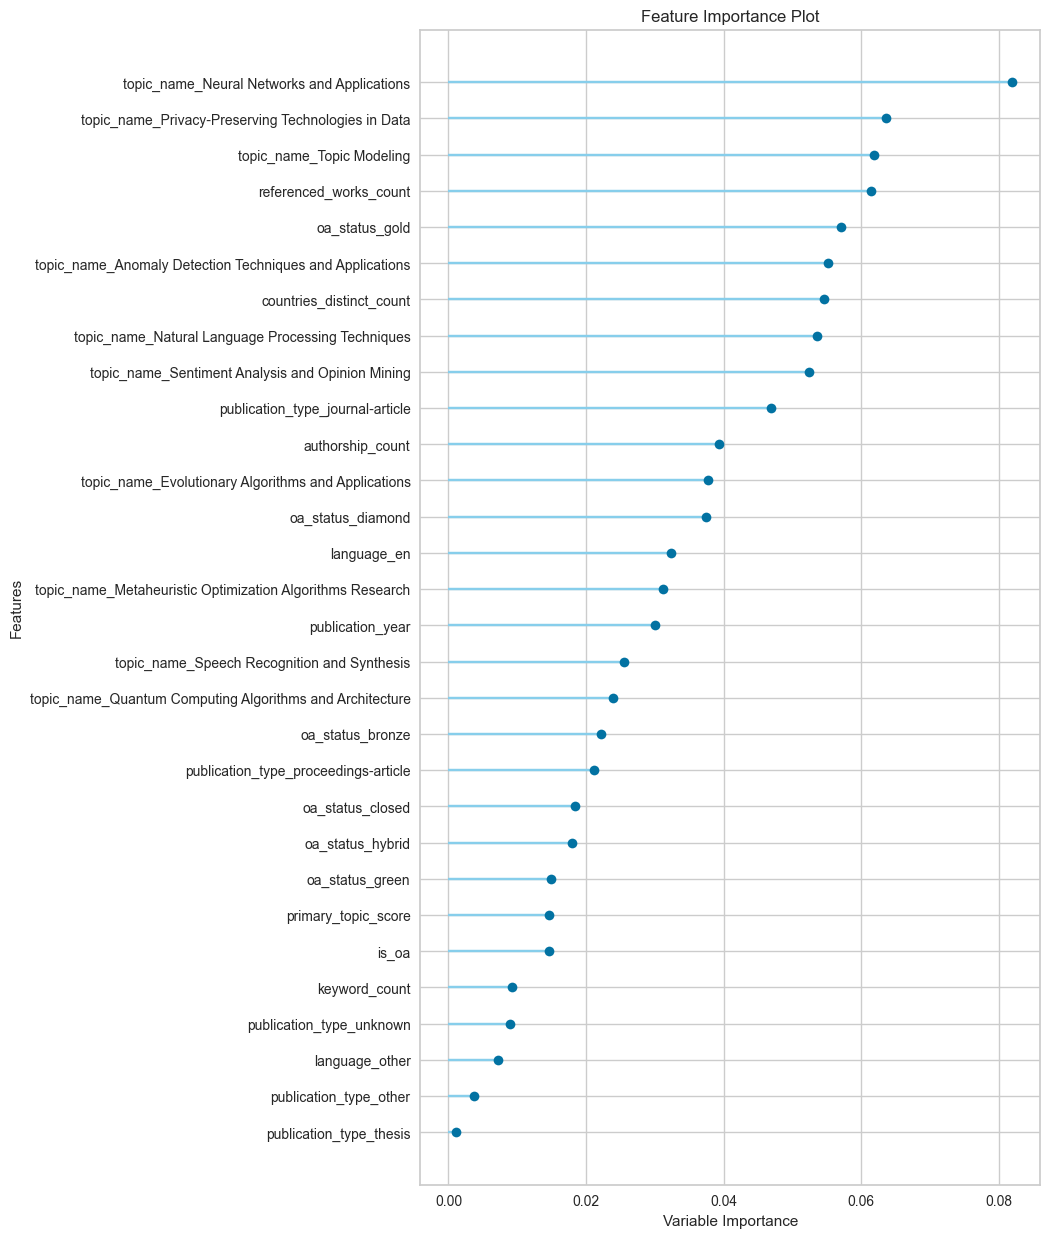

In [14]:
plot_model(xgboost_model, plot='confusion_matrix')
plot_model(xgboost_model, plot='auc')
plot_model(xgboost_model, plot='pr')
plot_model(xgboost_model, plot='class_report')
plot_model(xgboost_model, plot='feature_all')